In [3]:
# Inputs: Fire Occurrences, Urban Areas 

# Outputs: Occurrence Urban Intersect

# Purpose:Get wildfires that started outside urban areas


In [1]:
import pandas as pd 
import geopandas
import matplotlib.pyplot as plt



C:\Users\jezkn\Anaconda3\lib\site-packages\geopandas\plotting.py:51: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom is not None and geom.type.startswith(prefix) and not geom.is_empty:


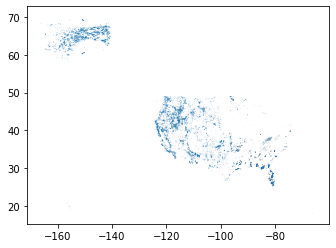

In [2]:
burn_df = geopandas.read_file(r"C:\Users\jezkn\Local\Data Science Projects\MSc Project Data\Data\Validation\mtbs_perimeter_data\mtbs_perims_DD.shp")
burn_df.plot()
plt.show()

In [3]:
burn_df.head()

,event_id,irwinid,incid_name,incid_type,map_id,map_prog,asmnt_type,burnbndac,burnbndlat,burnbndlon,...,perim_id,dnbr_offst,dnbr_stddv,nodata_t,incgreen_t,low_t,mod_t,high_t,comment,geometry
0,UT4176411148820121004,None,HELLS HOLLOW,Prescribed Fire,414,MTBS,Extended,4756,41.758473156859054,-111.50798253189413,...,703803120121020,47.0,NaN,-970.0,-150.0,113,345,616,None,"POLYGON ((-111.50122 41.80182, -111.50137 41.8..."
1,WA4796812059020120908,None,KLONE PEAK,Wildfire,441,MTBS,Extended,1634,47.97210056744996,-120.58152319121741,...,704502720121005,25.0,NaN,-970.0,-150.0,50,250,460,None,"POLYGON ((-120.58043 47.95900, -120.58007 47.9..."
2,WA4797012073420120908,None,BASALT,Wildfire,444,MTBS,Extended,1704,47.96732536523251,-120.74488707191695,...,704502720121005,-4.0,NaN,-970.0,-150.0,60,250,500,None,"POLYGON ((-120.75453 47.97945, -120.75434 47.9..."
3,WA4805112058820120908,None,PYRAMID,Wildfire,449,MTBS,Extended,1962,48.04473595599768,-120.5812261951236,...,None,74.0,NaN,-970.0,-150.0,120,220,530,None,"POLYGON ((-120.56115 48.04776, -120.56106 48.0..."
4,WA4788612026820120908,None,FIRST CREEK,Wildfire,454,MTBS,Extended,1434,47.895975428626414,-120.2604924836339,...,704502720120919,-37.0,NaN,-970.0,-150.0,50,200,460,None,"POLYGON ((-120.25525 47.89510, -120.25569 47.8..."


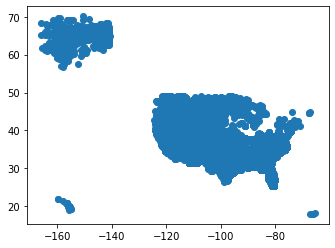

In [48]:
occurrences_df = geopandas.read_file(r"C:\Users\jezkn\Local\Data Science Projects\MSc Project Data\Data\Validation\mtbs_fod_pts_data\mtbs_FODpoints_DD.shp")
occurrences_df.plot()
plt.show()

In [49]:
occurrences_df.columns

Index(['event_id', 'irwinid', 'incid_name', 'incid_type', 'map_id', 'map_prog',
       'asmnt_type', 'burnbndac', 'burnbndlat', 'burnbndlon', 'ig_date',
       'pre_id', 'post_id', 'perim_id', 'dnbr_offst', 'dnbr_stddv', 'nodata_t',
       'incgreen_t', 'low_t', 'mod_t', 'high_t', 'comment', 'geometry'],
      dtype='object')

In [50]:
occurrences_df["ig_date"] = occurrences_df["ig_date"] = pd.to_datetime(occurrences_df["ig_date"])
occurrences_df = occurrences_df[occurrences_df["ig_date"] > "2024-12-31"]
occurrences_df.head()

,event_id,irwinid,incid_name,incid_type,map_id,map_prog,asmnt_type,burnbndac,burnbndlat,burnbndlon,...,perim_id,dnbr_offst,dnbr_stddv,nodata_t,incgreen_t,low_t,mod_t,high_t,comment,geometry
29919,TX3632910272820250318,EB8944B2-67F1-46F3-8926-3B9BFF3EEFDC,HIGH LONESOME,Wildfire,10032997,MTBS,Initial,24490,36.41493694055366,-102.5994235231072,...,None,15.0,9.0,-970.0,-150.0,45,9999,9999,None,POINT (-102.59942 36.41494)
29925,NM3586210475920250314,7C293856-FFC6-4BD9-97C2-4EA8917667B7,MOGOTE HILL,Wildfire,10033012,MTBS,Initial,17469,35.850345790841196,-104.6948825531825,...,None,21.0,5.0,-970.0,-150.0,40,9999,9999,None,POINT (-104.69488 35.85035)
29943,SD4465410198420250310,176FB73F-5FA3-4902-96F7-B4B897F25604,ROUTE 13,Wildfire,10033038,MTBS,Initial,34447,44.6870693101975,-101.84227869317823,...,None,33.0,29.0,-970.0,-150.0,85,9999,9999,None,POINT (-101.84228 44.68707)
29949,NE4185910104020250225,24F3B667-8EB9-4F17-9C93-BDEA34E3AAFA,DISMAL RIVER RANCH,Wildfire,10033045,MTBS,Initial,16088,41.78861628081379,-100.98318408926657,...,None,8.0,19.0,-970.0,-150.0,60,9999,9999,None,POINT (-100.98318 41.78862)
29951,TX3604510084520250314,A7BE56AE-3D78-4BBD-8063-188FE0F96E5A,WINDMILL,Wildfire,10033047,MTBS,Initial,23924,36.06960022791254,-100.7319597261261,...,None,0.0,11.0,-970.0,-150.0,20,9999,9999,None,POINT (-100.73196 36.06960)


In [51]:
len(occurrences_df)

87

In [52]:
#urban_df = geopandas.read_file(r"C:\Users\jezkn\Local\Data Science Projects\MSc Project Data\Data\WUI\Urban Areas\tl_2020_us_uac20.shp")
#urban_df.plot()
#plt.show()

In [53]:
urban_2020 = geopandas.read_file(r"C:\Users\jezkn\Local\Data Science Projects\MSc Project Data\Data\WUI\Urban Areas\tl_2020_us_uac20.shp")
urban_2020.head()

,UACE20,GEOID20,NAME20,NAMELSAD20,LSAD20,MTFCC20,UATYP20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,geometry
0,67240,67240,"Pampa, TX","Pampa, TX Urban Area",67,G3500,U,S,21374659,0,+35.5451610,-100.9656498,"POLYGON ((-100.94529 35.53833, -100.94525 35.5..."
1,23230,23230,"Delta, CO","Delta, CO Urban Area",67,G3500,U,S,16126572,129608,+38.7454236,-108.0619343,"POLYGON ((-108.04131 38.74094, -108.04100 38.7..."
2,36001,36001,"Gunnison, CO","Gunnison, CO Urban Area",67,G3500,U,S,9468678,11725,+38.5405505,-106.9384998,"POLYGON ((-106.92674 38.53565, -106.92795 38.5..."
3,45775,45775,"Kuna, ID","Kuna, ID Urban Area",67,G3500,U,S,16384896,46009,+43.5010643,-116.4168990,"MULTIPOLYGON (((-116.39896 43.48833, -116.3988..."
4,05410,05410,"Basalt, CO","Basalt, CO Urban Area",67,G3500,U,S,9433311,68797,+39.3835983,-107.0807354,"MULTIPOLYGON (((-107.11050 39.40463, -107.1104..."


In [54]:
burn_df.columns

Index(['event_id', 'irwinid', 'incid_name', 'incid_type', 'map_id', 'map_prog',
       'asmnt_type', 'burnbndac', 'burnbndlat', 'burnbndlon', 'ig_date',
       'pre_id', 'post_id', 'perim_id', 'dnbr_offst', 'dnbr_stddv', 'nodata_t',
       'incgreen_t', 'low_t', 'mod_t', 'high_t', 'comment', 'geometry'],
      dtype='object')

In [55]:
burn_2020 = burn_df[burn_df["ig_date"] > "2024-12-31"]
#burn_2010 = burn_df[(burn_df["YEAR"] > 2009) & (burn_df["YEAR"] <= 2019)]
#burn_2000 = burn_df[burn_df["YEAR"] <= 2010]

In [56]:
urban_fire_df_2020 = geopandas.sjoin(burn_2020, urban_2020, op='intersects')
#urban_fire_df_2010 = geopandas.sjoin(burn_2010, urban_2010, op='intersects')
#urban_fire_df_2000 = geopandas.sjoin(burn_2000, urban_2000, op='intersects')

C:\Users\jezkn\Anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3248: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if (await self.run_code(code, result,  async_=asy)):


In [57]:
occ_2020 = occurrences_df[occurrences_df["ig_date"] > "2024-12-31"]
#occ_2010 = occurrences_df[(occurrences_df["IG_DATE"] > "2009-12-31") & (occurrences_df["IG_DATE"] <= "2019-12-31")]
#occ_2000 = occurrences_df[occurrences_df["IG_DATE"] <= "2009-12-31"]

In [58]:
occ_df_2020 = geopandas.sjoin(occ_2020, urban_2020, op='intersects')
#occ_df_2010 = geopandas.sjoin(occ_2010, urban_2010, op='intersects')
#occ_df_2000 = geopandas.sjoin(occ_2000, urban_2000, op='intersects')

C:\Users\jezkn\Anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3248: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if (await self.run_code(code, result,  async_=asy)):


In [59]:
urban_fire_df = urban_fire_df_2020 #pd.concat([urban_fire_df_2020, urban_fire_df_2010, urban_fire_df_2000])
urban_fire_df['CrossedWUI'] = 1
len(urban_fire_df)

1

In [60]:
occ_fire_df =  occ_df_2020 #pd.concat([occ_df_2020, occ_df_2010, occ_df_2000])
occ_fire_df['UrbanOccurrence'] = 1
len(occ_fire_df)

0

In [61]:
urban_fire_lookup = urban_fire_df[['event_id', 'CrossedWUI']]
occ_fire_lookup = occ_fire_df[['event_id', 'UrbanOccurrence']]
urban_fire_lookup.head()

,event_id,CrossedWUI
30910,TX3494210195520260514,1


In [62]:
urban_fire_lookup = urban_fire_lookup.drop_duplicates()
occ_fire_lookup = occ_fire_lookup.drop_duplicates()
urban_fire_lookup.head(1000)

,event_id,CrossedWUI
30910,TX3494210195520260514,1


In [63]:
occ2 = pd.merge(urban_fire_lookup, occ_fire_lookup, on = ['event_id'], how='left')
occ2['CrossedWUI'].fillna(0, inplace=True)
occ2['UrbanOccurrence'].fillna(0, inplace=True)
occ2.head()

,event_id,CrossedWUI,UrbanOccurrence
0,TX3494210195520260514,1,0.0


In [64]:
occ2 = pd.merge(occurrences_df, occ2, on = ['event_id'], how='left')
occ2['CrossedWUI'].fillna(0, inplace=True)
occ2['UrbanOccurrence'].fillna(0, inplace=True)
occ2.head()

,event_id,irwinid,incid_name,incid_type,map_id,map_prog,asmnt_type,burnbndac,burnbndlat,burnbndlon,...,dnbr_stddv,nodata_t,incgreen_t,low_t,mod_t,high_t,comment,geometry,CrossedWUI,UrbanOccurrence
0,TX3632910272820250318,EB8944B2-67F1-46F3-8926-3B9BFF3EEFDC,HIGH LONESOME,Wildfire,10032997,MTBS,Initial,24490,36.41493694055366,-102.5994235231072,...,9.0,-970.0,-150.0,45,9999,9999,None,POINT (-102.59942 36.41494),0.0,0.0
1,NM3586210475920250314,7C293856-FFC6-4BD9-97C2-4EA8917667B7,MOGOTE HILL,Wildfire,10033012,MTBS,Initial,17469,35.850345790841196,-104.6948825531825,...,5.0,-970.0,-150.0,40,9999,9999,None,POINT (-104.69488 35.85035),0.0,0.0
2,SD4465410198420250310,176FB73F-5FA3-4902-96F7-B4B897F25604,ROUTE 13,Wildfire,10033038,MTBS,Initial,34447,44.6870693101975,-101.84227869317823,...,29.0,-970.0,-150.0,85,9999,9999,None,POINT (-101.84228 44.68707),0.0,0.0
3,NE4185910104020250225,24F3B667-8EB9-4F17-9C93-BDEA34E3AAFA,DISMAL RIVER RANCH,Wildfire,10033045,MTBS,Initial,16088,41.78861628081379,-100.98318408926657,...,19.0,-970.0,-150.0,60,9999,9999,None,POINT (-100.98318 41.78862),0.0,0.0
4,TX3604510084520250314,A7BE56AE-3D78-4BBD-8063-188FE0F96E5A,WINDMILL,Wildfire,10033047,MTBS,Initial,23924,36.06960022791254,-100.7319597261261,...,11.0,-970.0,-150.0,20,9999,9999,None,POINT (-100.73196 36.06960),0.0,0.0


In [65]:
occ2.columns.tolist()

['event_id',
 'irwinid',
 'incid_name',
 'incid_type',
 'map_id',
 'map_prog',
 'asmnt_type',
 'burnbndac',
 'burnbndlat',
 'burnbndlon',
 'ig_date',
 'pre_id',
 'post_id',
 'perim_id',
 'dnbr_offst',
 'dnbr_stddv',
 'nodata_t',
 'incgreen_t',
 'low_t',
 'mod_t',
 'high_t',
 'comment',
 'geometry',
 'CrossedWUI',
 'UrbanOccurrence']

In [66]:
occ2.rename(columns={'event_id': 'FIRE_ID', 'incid_type': 'FIRE_TYPE', 'ig_date': 'IG_DATE', 'burnbndlat': 'LATITUDE', 'burnbndlon': 'LONGITUDE', 'incid_name': 'FIRE_NAME'}, inplace=True)

In [67]:
occ4 = occ2[['FIRE_ID','FIRE_NAME','FIRE_TYPE','IG_DATE','LATITUDE','LONGITUDE','geometry','CrossedWUI','UrbanOccurrence']]
occ4 = occ4[occ4['UrbanOccurrence'] == 0]
occ4['IG_DATE'] = occ4['IG_DATE'].astype(str)
len(occ4)

87

In [68]:
occ3 = occ4[occ4['UrbanOccurrence'] == 1]
occ3.head()

,FIRE_ID,FIRE_NAME,FIRE_TYPE,IG_DATE,LATITUDE,LONGITUDE,geometry,CrossedWUI,UrbanOccurrence


In [69]:
occ4 = occ4[occ4['IG_DATE'] > '2024-12-31']
print(occ4.head())

                 FIRE_ID           FIRE_NAME FIRE_TYPE     IG_DATE  \
0  TX3632910272820250318       HIGH LONESOME  Wildfire  2025-03-18   
1  NM3586210475920250314         MOGOTE HILL  Wildfire  2025-03-14   
2  SD4465410198420250310            ROUTE 13  Wildfire  2025-03-10   
3  NE4185910104020250225  DISMAL RIVER RANCH  Wildfire  2025-02-25   
4  TX3604510084520250314            WINDMILL  Wildfire  2025-03-14   

             LATITUDE            LONGITUDE                     geometry  \
0   36.41493694055366   -102.5994235231072  POINT (-102.59942 36.41494)   
1  35.850345790841196   -104.6948825531825  POINT (-104.69488 35.85035)   
2    44.6870693101975  -101.84227869317823  POINT (-101.84228 44.68707)   
3   41.78861628081379  -100.98318408926657  POINT (-100.98318 41.78862)   
4   36.06960022791254   -100.7319597261261  POINT (-100.73196 36.06960)   

   CrossedWUI  UrbanOccurrence  
0         0.0              0.0  
1         0.0              0.0  
2         0.0              0.

In [70]:
occ4.to_file(r"C:\Users\jezkn\OneDrive\Documents\Birkbeck\Work\MSc Project\Wildfire Project\Outputs\VALIDATION_PartOneOutput.shp")

C:\Users\jezkn\Anaconda3\lib\site-packages\ipykernel_launcher.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  """Entry point for launching an IPython kernel.


In [71]:
occ6 = occ4[['FIRE_ID','CrossedWUI']]
occ6.groupby(['CrossedWUI']).size()

CrossedWUI
0.0    86
1.0     1
dtype: int64